---
numbering: false
---

# 1.5: Length and distance

In [Chapter 1.4](01-04.ipynb), we learned how to add and scale vectors. Now, let's look more closely at their geometry. How do we find the length of a vector? And how can we use vectors to find the distance between two points?


---

## Length of a vector

### Review: The Pythagorean theorem

Throughout Chapter 1.5, we will refer to the familiar Pythagorean theorem. Recall, this says that if $c$ is the length of the hypotenuse (the longest side) of a **right** triangle, and $a$ and $b$ are the side lengths of its two legs, then $$a^2 + b^2 = c^2.$$

For example, a right triangle with legs of lengths 5 and 12 has a hypotenuse of length $\sqrt{5^2+12^2}=\sqrt{169}=13$.


In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path as _PlotPath
import sys as _plot_sys

_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly


def _vector_figure(vectors, vdeltax=0.3, vdeltay=0.3, vdeltaz=0.3):
    dimension = len(vectors[0][0][0])
    fig = go.Figure()

    for (start, end), color, label in vectors:
        start = np.asarray(start, dtype=float)
        end = np.asarray(end, dtype=float)
        delta = end - start

        if dimension == 2:
            fig.add_trace(go.Scatter(
                x=[start[0], end[0]], y=[start[1], end[1]], mode="lines",
                line=dict(color=color, width=4), showlegend=False,
                hovertemplate="(%{x}, %{y})<extra></extra>",
            ))
            fig.add_annotation(
                x=end[0], y=end[1], ax=start[0], ay=start[1],
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=3,
                arrowcolor=color,
            )
            if label:
                midpoint = (start + end) / 2
                fig.add_annotation(
                    x=midpoint[0] + vdeltax, y=midpoint[1] + vdeltay,
                    text=label, showarrow=False, font=dict(color=color, size=16),
                )
        else:
            fig.add_trace(go.Scatter3d(
                x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
                mode="lines", line=dict(color=color, width=8),
                showlegend=False, hoverinfo="skip",
            ))
            length = np.linalg.norm(delta)
            if length:
                unit = delta / length
                fig.add_trace(go.Cone(
                    x=[end[0]], y=[end[1]], z=[end[2]],
                    u=[unit[0]], v=[unit[1]], w=[unit[2]],
                    anchor="tip", sizemode="absolute", sizeref=0.28,
                    colorscale=[[0, color], [1, color]], showscale=False,
                    hoverinfo="skip",
                ))
            if label:
                midpoint = (start + end) / 2
                fig.add_trace(go.Scatter3d(
                    x=[midpoint[0] + vdeltax], y=[midpoint[1] + vdeltay],
                    z=[midpoint[2] + vdeltaz], mode="text", text=[label],
                    textfont=dict(color=color, size=16), hoverinfo="skip",
                    showlegend=False,
                ))

    return fig


def plot_vectors_non_origin(vectors, **kwargs):
    return _vector_figure(vectors, **kwargs)


def plot_vectors(vectors, **kwargs):
    converted = []
    for endpoint, color, label in vectors:
        converted.append(((tuple(0 for _ in endpoint), endpoint), color, label))
    return _vector_figure(converted, **kwargs)


def _set_vector_colors(fig, vectors, overrides):
    if np.asarray(vectors[0][0]).ndim == 1:
        vectors = [((tuple(0 for _ in endpoint), endpoint), color, label) for endpoint, color, label in vectors]
    dimension = len(vectors[0][0][0])
    trace_index = 0
    annotation_index = 0

    for vector_index, ((start, end), _, label) in enumerate(vectors):
        color = overrides.get(vector_index)
        if dimension == 2:
            if color:
                fig.data[trace_index].line.color = color
                fig.layout.annotations[annotation_index].arrowcolor = color
                if label:
                    fig.layout.annotations[annotation_index + 1].font.color = color
            trace_index += 1
            annotation_index += 1 + bool(label)
        else:
            if color:
                fig.data[trace_index].line.color = color
            trace_index += 1
            if np.linalg.norm(np.asarray(end) - np.asarray(start)):
                if color:
                    fig.data[trace_index].colorscale = [[0, color], [1, color]]
                trace_index += 1
            if label:
                if color:
                    fig.data[trace_index].textfont.color = color
                trace_index += 1

    return fig


def finish_vectors(fig, vectors, renderer="png"):
    _style_plotly(fig, renderer=renderer)
    _set_vector_colors(fig, vectors, {i: item[1] for i, item in enumerate(vectors)})
    return fig

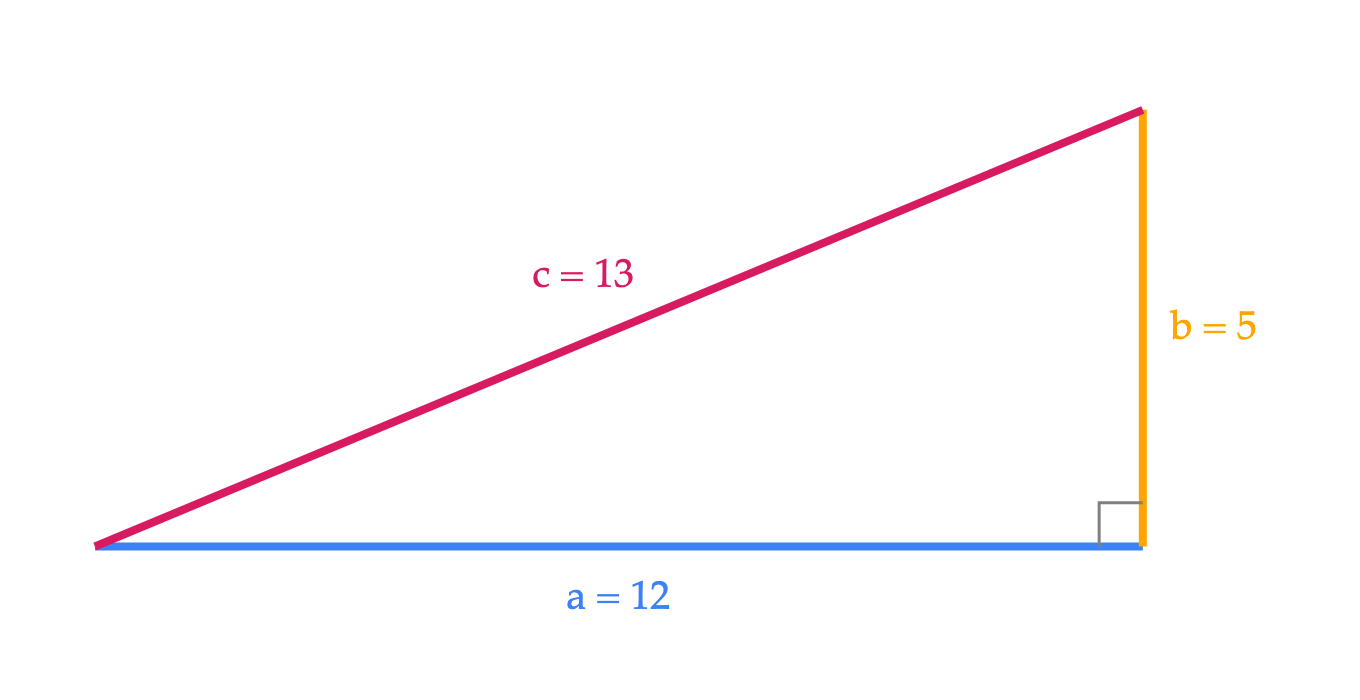

In [2]:
fig = go.Figure()
for x, y, color in [([0, 12], [0, 0], '#3d81f6'),
                     ([12, 12], [0, 5], 'orange'),
                     ([0, 12], [0, 5], '#d81a60')]:
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines',
        line=dict(color=color, width=4), showlegend=False, hoverinfo='skip'))
_style_plotly(fig, renderer='png')
for x, y, label, color in [(6, -0.6, 'a = 12', '#3d81f6'),
                            (12.8, 2.5, 'b = 5', 'orange'),
                            (5.6, 3.1, 'c = 13', '#d81a60')]:
    fig.add_annotation(x=x, y=y, text=label, showarrow=False,
        font=dict(size=20, color=color))
fig.add_shape(type='path', path='M 11.5,0 L 11.5,0.5 L 12,0.5',
    line=dict(color='gray', width=1.5))
fig.update_layout(width=680, height=350, margin=dict(l=20,r=20,t=20,b=20))
fig.update_xaxes(visible=False, range=[-0.6,14], constrain='domain')
fig.update_yaxes(visible=False, range=[-1.3,5.8], scaleanchor='x', scaleratio=1)
fig.show(scale=2)

### Example in ℝ²

Now for our main point: finding the length of a vector. Let's start with the vector

$$\vec v = \begin{bmatrix} {\color{#3d81f6} 3} \\ {\color{orange} 4} \end{bmatrix}.$$

To draw $\vec v$ from the origin, we move ${\color{#3d81f6} 3}$ units to the right and ${\color{orange} 4}$ units up. The resulting arrow is the hypotenuse of a right triangle. The Pythagorean theorem tells us its length is

$$\sqrt{{\color{#3d81f6} 3}^2 + {\color{orange} 4}^2} = \sqrt{25} = 5.$$


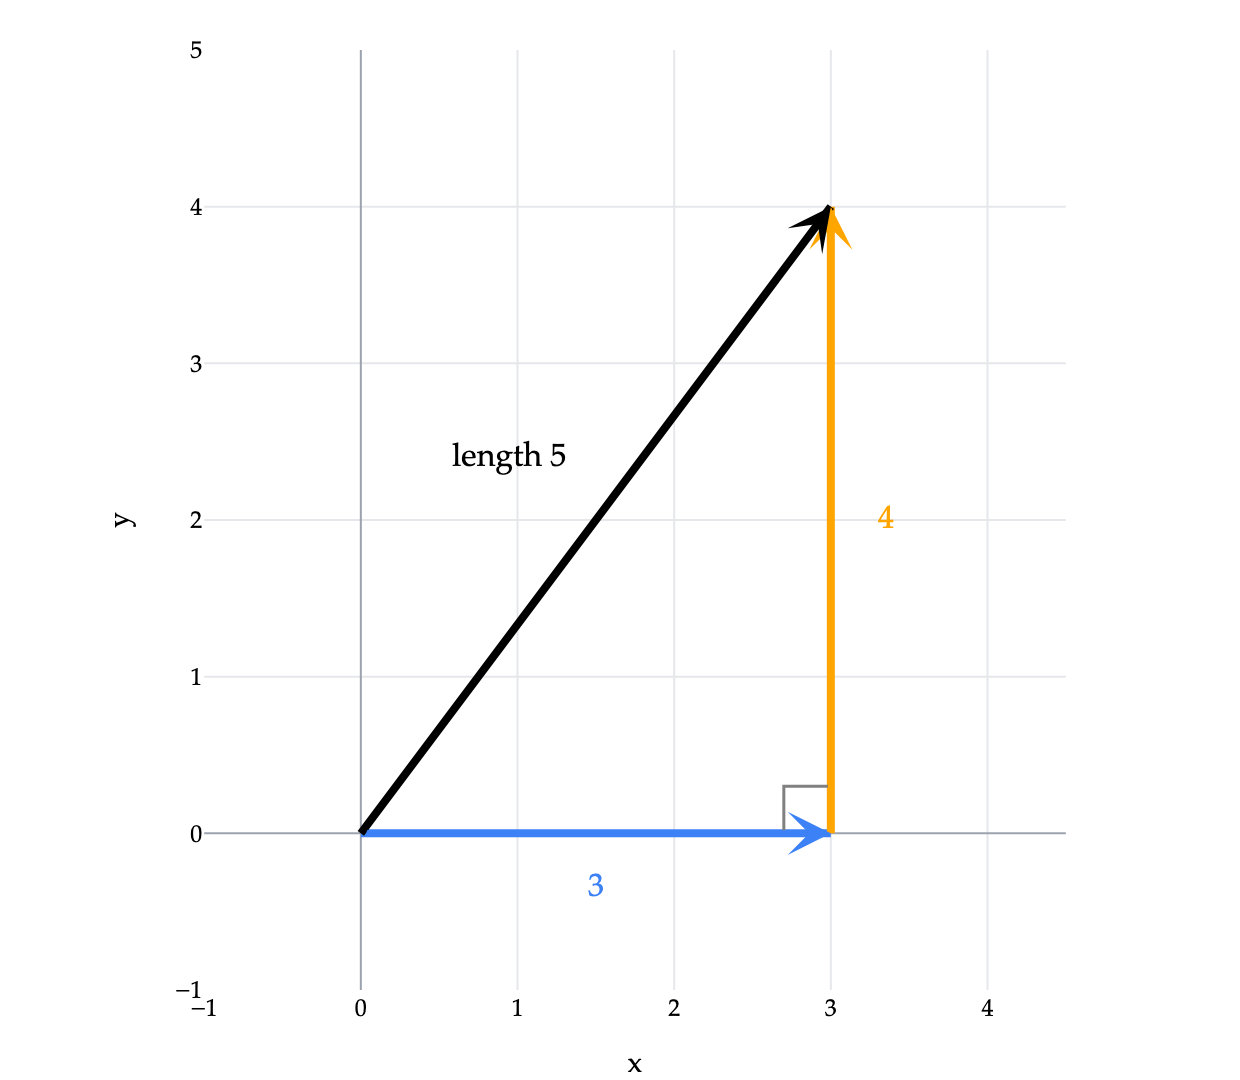

In [3]:
vectors = [
    (((0, 0), (3, 0)), '#3d81f6', '3'),
    (((3, 0), (3, 4)), 'orange', '4'),
    (((0, 0), (3, 4)), 'black', 'length 5'),
]
fig = plot_vectors_non_origin(vectors)
fig.layout.annotations[1].update(x=1.5, y=-0.35)
fig.layout.annotations[3].update(x=3.35, y=2)
fig.layout.annotations[5].update(x=0.95, y=2.4)
fig.add_shape(type='path', path='M 2.7,0 L 2.7,0.3 L 3,0.3', line=dict(color='gray', width=1.5))
fig.update_layout(width=620, height=540, xaxis_title='x', yaxis_title='y', margin=dict(l=45,r=30,t=25,b=45))
fig.update_xaxes(range=[-1, 4.5], dtick=1, constrain='domain')
fig.update_yaxes(range=[-1, 5], dtick=1, scaleanchor='x', scaleratio=1)
finish_vectors(fig, vectors)
fig.show(scale=2)

We use **norm** and **magnitude** as other words for length, and write the norm of $\vec v$ as $\lVert \vec v \rVert$. Here, $\lVert \vec v \rVert = 5$.

### Example in ℝ³

What if we add a third component? Consider

$$\vec v = \begin{bmatrix} {\color{gray} 3} \\ {\color{gray} 4} \\ {\color{orange} -2} \end{bmatrix}.$$

In [4]:
vectors = [
    (((0, 0, 0), (3, 0, 0)), 'gray', '3'),
    (((3, 0, 0), (3, 4, 0)), 'gray', '4'),
    (((0, 0, 0), (3, 4, 0)), '#3d81f6', 'length 5'),
    (((3, 4, 0), (3, 4, -2)), 'orange', 'length 2'),
    (((0, 0, 0), (3, 4, -2)), 'black', 'length √29'),
]
fig = plot_vectors_non_origin(vectors, vdeltax=0.15, vdeltay=0.15, vdeltaz=0.2)
fig.update_layout(width=590, height=520, margin=dict(l=0,r=0,t=15,b=0),
    scene=dict(xaxis=dict(title='x',range=[-0.5,4],dtick=1),
               yaxis=dict(title='y',range=[-0.5,5],dtick=1),
               zaxis=dict(title='z',range=[-3,1],dtick=1),
               aspectmode='data', camera=dict(eye=dict(x=1.6,y=-1.8,z=1.1))))
fig.data[11].update(x=[3.35], y=[4.45], z=[-1.0], textposition='middle right')
fig.data[14].update(x=[1.1], y=[2.0], z=[-1.1])
finish_vectors(fig, vectors, renderer='plotly_mimetype')
fig.show()

Drag the figure above to see the two right triangles mentioned below from different viewpoints.

We can find its length by applying the Pythagorean theorem **twice**. First, move ${\color{gray} 3}$ units in the $x$ direction and ${\color{gray} 4}$ units in the $y$ direction. The blue diagonal in the $xy$-plane has length

$$\sqrt{{\color{gray} 3}^2 + {\color{gray} 4}^2} = {\color{#3d81f6} 5}.$$

The third component is ${\color{orange} -2}$, so we move ${\color{orange} 2}$ units downward. This vertical segment is perpendicular to the $xy$-plane, so we get another right triangle. Its legs have lengths ${\color{#3d81f6} 5}$ and ${\color{orange} 2}$, and its hypotenuse is our original vector. Therefore,

$$\lVert \vec v \rVert = \sqrt{{\color{#3d81f6} 5}^2 + {\color{orange} 2}^2} = \sqrt{29}.$$

Notice that this is the same as taking the square root of the sum of the squares of all three components:

$$\lVert \vec v \rVert = \sqrt{{\color{gray} 3}^2 + {\color{gray} 4}^2 + {\color{orange} (-2)}^2}.$$

### Formal definition

The same pattern gives us a **definition** for any number of components.

:::{note} Definition: Length of a vector
For a vector ${\color{#3d81f6} \vec v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix} \in \mathbb{R}^n$, its **length**, also called its **norm** or **magnitude**, is

$$\lVert {\color{#3d81f6} \vec v} \rVert = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}.$$
:::

As another example,

$$\left\lVert \begin{bmatrix} -1 \\ 2 \\ 0 \\ -2 \end{bmatrix} \right\rVert
= \sqrt{(-1)^2 + 2^2 + 0^2 + (-2)^2} = \sqrt{9} = 3.$$

This vector has four components, but its length is 3. Those are different quantities! This is a vector in $\mathbb{R}^4$, which means we can't visualize it, but we still measure its length by this definition.

---

## Scaling

What happens to a vector's length when we scale it? If ${\color{#3d81f6} \vec v}$ has length 5, then $2{\color{#3d81f6} \vec v}$ has length 10. So does $-2{\color{#3d81f6} \vec v}$: the minus sign reverses the direction, but the arrow is still twice as long.

:::{note} Properties of length
For any vector ${\color{#3d81f6} \vec v}$ and any scalar ${\color{orange} c}$:

- $\lVert {\color{#3d81f6} \vec v} \rVert \geq 0$. Lengths cannot be negative.
- $\lVert {\color{#3d81f6} \vec v} \rVert = 0$ exactly when ${\color{#3d81f6} \vec v} = \vec 0$.
- $\lVert {\color{orange} c}{\color{#3d81f6} \vec v} \rVert = |{\color{orange} c}|\lVert {\color{#3d81f6} \vec v} \rVert$. Scaling by ${\color{orange} c}$ multiplies the length by $|{\color{orange} c}|$.
:::

Why the absolute value in the last property? The length formula squares each component, so a factor of ${\color{orange} c}$ contributes ${\color{orange} c}^2$ under the square root. Taking the square root gives $\sqrt{{\color{orange} c}^2}=|{\color{orange} c}|$. The sign affects the direction, but the length stays nonnegative.

For now, to find the length of a linear combination such as $2{\color{orange} \vec u} - {\color{#3d81f6} \vec v}$, compute the vector first, then take its norm.

::::{tip} Activity 1
Let

$$\vec u = \begin{bmatrix} 6 \\ -8 \end{bmatrix}, \qquad
\vec v = \begin{bmatrix} -6 \\ 2 \end{bmatrix}.$$

1. Find $\lVert \vec u \rVert$ and $\lVert \vec v \rVert$.
2. Find $\lVert \vec u + \vec v \rVert$.
3. Find $\lVert 2\vec u - \vec v \rVert$.
4. Find $\lVert -3\vec v \rVert$ in two ways: by computing $-3\vec v$ first, and by using the scaling property.
5. Is $\lVert \vec u + \vec v \rVert$ equal to $\lVert \vec u \rVert + \lVert \vec v \rVert$?

:::{tip} Solution
:class: dropdown

1. $\lVert \vec u \rVert = \sqrt{6^2+(-8)^2} = 10$ and $\lVert \vec v \rVert = \sqrt{(-6)^2+2^2} = 2\sqrt{10}$.
2. $\vec u + \vec v = \begin{bmatrix} 0 \\ -6 \end{bmatrix}$, so $\lVert \vec u + \vec v \rVert = \sqrt{0^2+(-6)^2} = 6$.
3. $2\vec u - \vec v = \begin{bmatrix} 12-(-6) \\ -16-2 \end{bmatrix} = \begin{bmatrix} 18 \\ -18 \end{bmatrix}$, so its norm is $\sqrt{18^2+(-18)^2} = 18\sqrt{2}$.
4. $-3\vec v = \begin{bmatrix} 18 \\ -6 \end{bmatrix}$, whose norm is $\sqrt{18^2+(-6)^2} = 6\sqrt{10}$. The scaling property gives the same answer: $|-3|\lVert \vec v \rVert = 3\cdot 2\sqrt{10} = 6\sqrt{10}$.
5. No: $6 \neq 10+2\sqrt{10}$. Adding vectors does not usually add their lengths.
:::
::::


---

## The triangle inequality

Notice something in the earlier activity. In Activity 1, we found that $\lVert\vec u+\vec v\rVert=6$, while $\lVert\vec u\rVert+\lVert\vec v\rVert=10+2\sqrt{10}$. The length of the sum is less than the sum of the lengths! This is an example of the **triangle inequality**.

Let's describe this another way. Imagine traveling from point $A$ to point $B$, then from point $B$ to point $C$. Let ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$ represent those two displacements, respectively. The direct displacement from $A$ to $C$ is the sum of the two vectors: ${\color{orange} \vec u} + {\color{#3d81f6} \vec v}$.


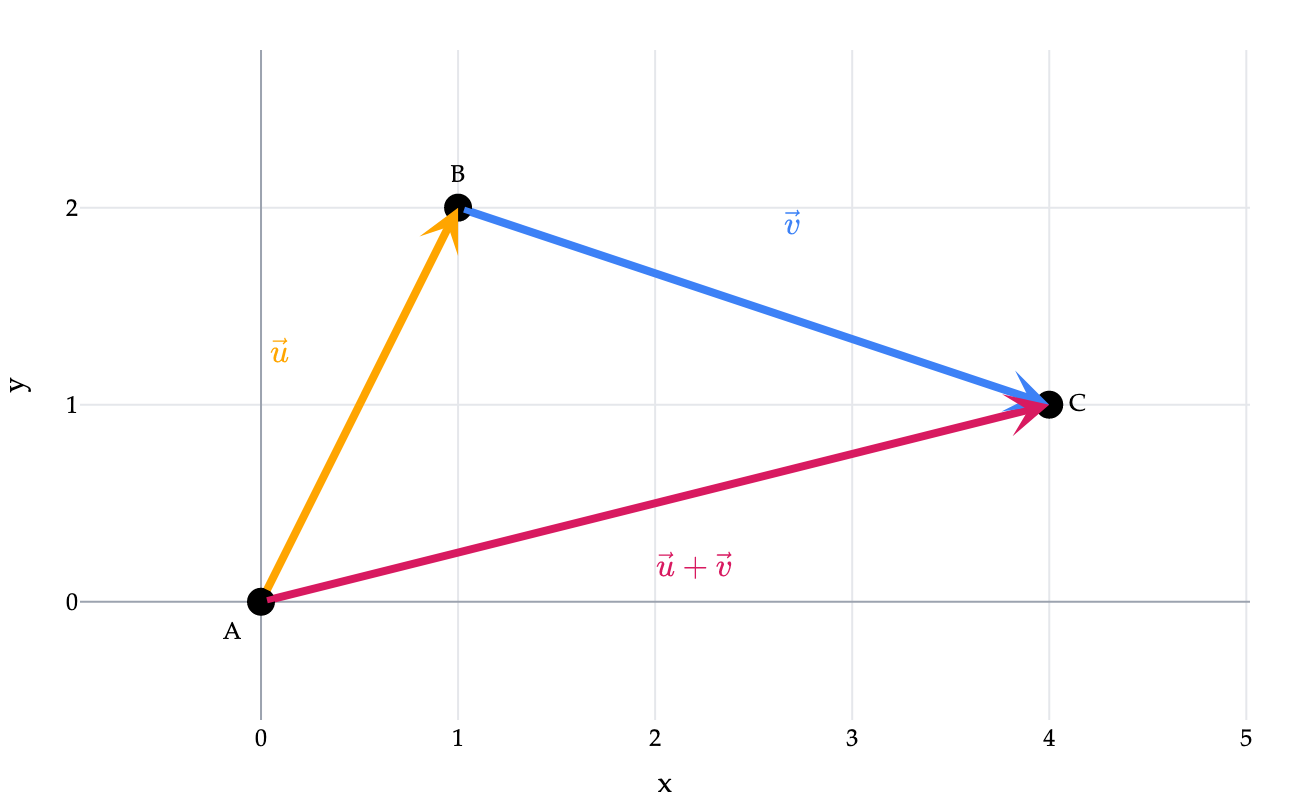

In [5]:
vectors = [
    (((0, 0), (1, 2)), 'orange', r'$\vec u$'),
    (((1, 2), (4, 1)), '#3d81f6', r'$\vec v$'),
    (((0, 0), (4, 1)), '#d81a60', r'$\vec u + \vec v$'),
]
fig = plot_vectors_non_origin(vectors)
fig.layout.annotations[1].update(x=0.1, y=1.3)
fig.layout.annotations[3].update(x=2.7, y=1.95)
fig.layout.annotations[5].update(x=2.2, y=0.2)
fig.update_layout(width=650, height=400, xaxis_title='x', yaxis_title='y', margin=dict(l=40,r=25,t=25,b=40))
fig.update_xaxes(range=[-0.7, 4.8], dtick=1)
fig.update_yaxes(range=[-0.6, 2.8], dtick=1, scaleanchor='x', scaleratio=1)
finish_vectors(fig, vectors)
fig.add_trace(go.Scatter(x=[0,1,4],y=[0,2,1],mode='markers+text',text=['A','B','C'],
    textposition=['bottom left','top center','middle right'],marker=dict(color='black',size=14),showlegend=False))
fig.show(scale=2)

**Key idea**: The straight path cannot be longer than the path through $B$. We can state this formally.

:::{note} Triangle inequality
For vectors ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$ with the same number of components,

$$\lVert {\color{orange} \vec u} + {\color{#3d81f6} \vec v} \rVert \leq \lVert {\color{orange} \vec u} \rVert + \lVert {\color{#3d81f6} \vec v} \rVert.$$
:::

The two sides can be equal. For example, if we travel ${\color{orange} 3}$ meters east and then another ${\color{#3d81f6} 4}$ meters east, our total displacement has length 7 meters. But if we change direction along the way, the direct route is shorter.

The picture explains the inequality in two dimensions. It also holds in $\mathbb{R}^n$, for any number of components. We'll use this fact without proving the general case here.


---

## Distance between points

To find the distance between two **points**, we find the length of the vector that connects them!

### Example in ℝ²

Consider the points ${\color{orange} B}={\color{orange} (-2,4)}$ and ${\color{#3d81f6} A}={\color{#3d81f6} (5,-1)}$. The vector ${\color{black} \vec d}$ from ${\color{orange} B}$ to ${\color{#3d81f6} A}$ describes the displacement from one point to the other.

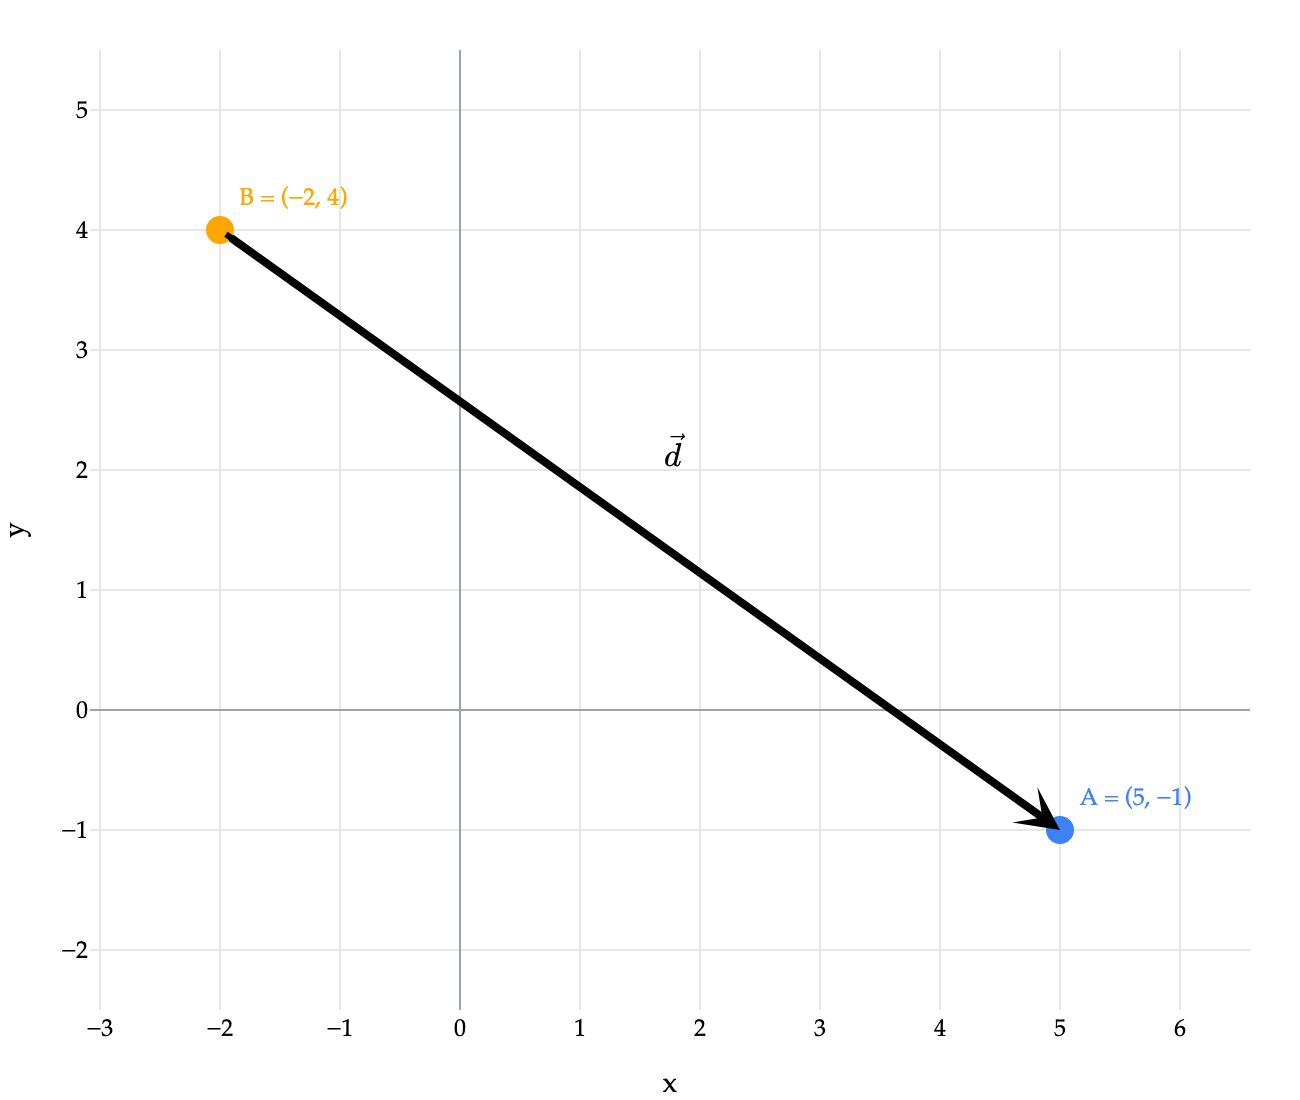

In [6]:
vectors = [
    (((-2, 4), (5, -1)), 'black', r'$\vec d$'),
]
fig = plot_vectors_non_origin(vectors)
fig.layout.annotations[1].update(x=1.8, y=2.2)
fig.update_layout(width=650,height=550,xaxis_title='x',yaxis_title='y',margin=dict(l=45,r=25,t=25,b=45))
fig.update_xaxes(range=[-3,6.5],dtick=1)
fig.update_yaxes(range=[-2.5,5.5],dtick=1,scaleanchor='x',scaleratio=1)
finish_vectors(fig,vectors)
fig.add_trace(go.Scatter(x=[5,-2],y=[-1,4],mode='markers+text',text=['A = (5, −1)','B = (−2, 4)'],
    textposition=['top right','top right'],textfont=dict(color=['#3d81f6','orange']),marker=dict(color=['#3d81f6','orange'],size=14),showlegend=False))
fig.show(scale=2)


To find ${\color{black} \vec d}$, subtract the starting coordinates from the ending coordinates:

$${\color{black} \vec d}=\begin{bmatrix}{\color{#3d81f6} 5}-{\color{orange} (-2)}\\{\color{#3d81f6} -1}-{\color{orange} 4}\end{bmatrix}
={\color{black} \begin{bmatrix}7\\-5\end{bmatrix}}.$$

The distance between the points is the length of this vector:

$$\lVert {\color{black} \vec d}\rVert=\sqrt{{\color{black} 7}^2+{\color{black} (-5)}^2}={\color{black} \sqrt{74}}\text{ units}\approx{\color{black} 8.60}\text{ units}.$$

A path between these points may take a detour and be longer. The length of $\color{black} \vec d$ gives the **straight-line distance** between the endpoints.

We sometimes use points and vectors interchangeably in coordinate calculations, but they play different roles: a point specifies a fixed position, while a vector describes a displacement. For example, ${\color{orange} B}$ is a particular location in the plane, while ${\color{black} \vec d}$ describes moving ${\color{black} 7}$ units to the right and ${\color{black} 5}$ units down, regardless of where we start.

The same method works with any number of coordinates: subtract corresponding coordinates, then take the norm. Reversing the direction gives the opposite displacement, $-{\color{black} \vec d}$, but the same distance, since $\lVert-{\color{black} \vec d}\rVert=\lVert{\color{black} \vec d}\rVert$.

### Example in ℝ³

Consider the points $P=(2,-3,0)$ and $Q=(-2,3,7)$.

The displacement from $P$ to $Q$ is

$$\begin{bmatrix}-2-2\\3-(-3)\\7-0\end{bmatrix}
=\begin{bmatrix}-4\\6\\7\end{bmatrix}.$$

The distance between the points is therefore

$$\sqrt{(-4)^2+6^2+7^2}=\sqrt{101}\text{ units}\approx 10.05\text{ units}.$$

The first coordinate decreases by 4 units. The negative sign tells us which way to move; it does not make the distance negative. Its contribution to the squared length is $(-4)^2=16$.

::::{tip} Activity 2
Let $T=(3,-1,4)$ and $P=(5,1,5)$.

1. Find the displacement from $T$ to $P$.
2. Find the distance between $T$ and $P$.
3. Each coordinate of $P$ is within 2 units of the corresponding coordinate of $T$. Does this mean that the distance between $P$ and $T$ is at most 2 units?

:::{tip} Solution
:class: dropdown

1. The displacement is $\begin{bmatrix}5-3\\1-(-1)\\5-4\end{bmatrix}=\begin{bmatrix}2\\2\\1\end{bmatrix}$ units.
2. The distance is $\sqrt{2^2+2^2+1^2}=\sqrt{9}=3$ units.
3. No: $3>2$. Each coordinate of $P$ differs from the corresponding coordinate of $T$ by at most 2 units, but the total distance is 3 units! Checking the coordinates separately is not enough; we need the norm of the displacement.
:::
::::


---

## Unit vectors

In [Chapter 1.4](01-04.ipynb), we noticed that the vectors

$$\begin{bmatrix}1\\2\end{bmatrix},\qquad
\begin{bmatrix}2\\4\end{bmatrix},\qquad
\begin{bmatrix}100\\200\end{bmatrix}$$

all point in the same direction, even though their lengths are different. We didn't yet have a precise way to describe their shared direction.

One way to describe a vector's direction is to use a vector of length 1 that points in that direction. We call a vector of length 1 a **unit vector**.

Let's start with ${\color{#3d81f6} \vec v}=\begin{bmatrix}1\\2\end{bmatrix}$. Its length is $\sqrt{1^2+2^2}=\sqrt{5}$. To give it length 1 while keeping its direction, we can scale it by $1/\sqrt{5}$:

$$\frac{1}{\sqrt{5}}\begin{bmatrix}1\\2\end{bmatrix}
=\begin{bmatrix}\frac{1}{\sqrt{5}}\\[4pt]\frac{2}{\sqrt{5}}\end{bmatrix}.$$

The resulting vector has length $\frac{1}{\sqrt{5}}\cdot\sqrt{5}=1$, and the positive scale factor preserves its direction. This is the unit vector that describes the direction of ${\color{#3d81f6} \vec v}$!

The other two vectors have lengths $2\sqrt{5}$ and $100\sqrt{5}$. Dividing each by its own length gives exactly the same unit vector. This makes their shared direction precise: two nonzero vectors point in the same direction exactly when they give the same unit vector after dividing by their lengths.

In general, to find a unit vector in the direction of any nonzero vector ${\color{#3d81f6} \vec v}$, divide it by its length:

$$\frac{{\color{#3d81f6} \vec v}}{\lVert {\color{#3d81f6} \vec v} \rVert}
=\frac{1}{\lVert {\color{#3d81f6} \vec v} \rVert}{\color{#3d81f6} \vec v}.$$

Dividing a vector by its length means multiplying every component by the same scalar, $1/\lVert{\color{#3d81f6} \vec v}\rVert$. We call this process **normalizing** a vector. The scaling property tells us that the result has length 1:

$$\left\lVert\frac{{\color{#3d81f6} \vec v}}{\lVert{\color{#3d81f6} \vec v}\rVert}\right\rVert
=\frac{1}{\lVert{\color{#3d81f6} \vec v}\rVert}\lVert{\color{#3d81f6} \vec v}\rVert=1.$$

Since $\lVert{\color{#3d81f6} \vec v}\rVert>0$, the scale factor is positive, so the direction stays the same. We cannot normalize $\vec 0$, since doing so would require dividing by 0.

::::{tip} Activity 3
Find a unit vector in the direction of $\vec w = \begin{bmatrix} 1 \\ -2 \\ -1 \end{bmatrix}$. Then find a vector of length 6 in that direction.

:::{tip} Solution
:class: dropdown

Since $\lVert \vec w \rVert = \sqrt{1^2+(-2)^2+(-1)^2} = \sqrt{6}$, the unit vector is

$$\frac{1}{\sqrt{6}}\begin{bmatrix}1\\-2\\-1\end{bmatrix}
=\begin{bmatrix}\frac{1}{\sqrt{6}}\\[4pt]-\frac{2}{\sqrt{6}}\\[4pt]-\frac{1}{\sqrt{6}}\end{bmatrix}.$$

Multiplying this unit vector by 6 gives

$$\frac{6}{\sqrt{6}}\begin{bmatrix}1\\-2\\-1\end{bmatrix}
=\begin{bmatrix}\sqrt{6}\\-2\sqrt{6}\\-\sqrt{6}\end{bmatrix},$$

which has length 6 and points in the same direction.
:::
::::

In [Chapter 1.6](01-06.ipynb), we'll use vector lengths to help measure **angles** between vectors.
